1. Téléchargement des bibliothèques

In [15]:
# -*- coding: utf-8 *-

#Vérification de l'environnement de travail
import sys
print(sys.executable)

# Chargement des bibliothèques
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, classification_report
from imblearn.over_sampling import RandomOverSampler

print("import terminé")

/opt/anaconda3/envs/Liora/bin/python
import terminé


2. Chargement des données et séparations des variables explicatives de la variable cible

In [16]:
#Import des jeux de données train, test et validation

chemin="/Users/antoine/Desktop/Liora/Projet/features/"

train=pd.read_csv(chemin+"train_features.csv", sep=",")
test=pd.read_csv(chemin+"test_features.csv", sep=",")
val=pd.read_csv(chemin+"validation_features.csv", sep=",")

display(train.head())

display(test.head())

display(val)

print(val.info())

classe_names=train["classe"].unique()

#Extraction des données explicatives et des classes

X_train, y_train = train.drop(columns=["filename", "classe"]), train["classe"]

X_test, y_test = test.drop(columns=["filename", "classe"]), test["classe"]

X_val, y_val = val.drop(columns=["filename", "classe"]), test["classe"]

print(f"Dimension de X_train {X_train.shape}, de X_test {X_test.shape} et de X_val {X_val.shape}.")
print(f"Dimension de y_train {y_train.shape}, de y_test {y_test.shape} et de y_val {y_val.shape}.")


,filename,classe,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien
0,COVID-1.png,COVID,144.7132,10.9031,0.234125,1779.5644
1,COVID-10.png,COVID,140.9981,10.8718,0.262670,2205.6332
2,COVID-1000.png,COVID,139.1298,10.8428,0.245299,1697.4293
3,COVID-1001.png,COVID,139.1082,10.9089,0.148320,1661.2844
4,COVID-1002.png,COVID,138.8807,10.7731,0.424201,2473.2524


,filename,classe,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien
0,COVID-1020.png,COVID,141.5724,10.8202,0.358150,2789.1094
1,COVID-1027.png,COVID,141.7071,10.8528,0.226239,1814.9503
2,COVID-1030.png,COVID,140.3077,10.8613,0.262838,2072.6794
3,COVID-1042.png,COVID,142.5702,10.8843,0.212637,2002.2903
4,COVID-1044.png,COVID,141.4174,10.8874,0.238968,1830.1202


,filename,classe,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien
0,COVID-101.png,COVID,142.3837,10.9156,0.250993,2219.7591
1,COVID-1018.png,COVID,143.9312,10.9175,0.217816,2053.4762
2,COVID-1022.png,COVID,142.4553,10.9098,0.204450,1611.2411
3,COVID-1037.png,COVID,141.1751,10.9135,0.156799,1673.4562
4,COVID-1038.png,COVID,144.2265,10.9259,0.195065,1628.6309
...,...,...,...,...,...,...
2078,Viral Pneumonia-960.png,Viral Pneumonia,135.1092,10.8278,0.224997,1872.4556
2079,Viral Pneumonia-963.png,Viral Pneumonia,137.8732,10.9273,0.197503,2021.8046
2080,Viral Pneumonia-977.png,Viral Pneumonia,140.0777,10.8271,0.284370,1775.8982
2081,Viral Pneumonia-988.png,Viral Pneumonia,139.3529,10.8466,0.234684,2232.7651


<class 'pandas.DataFrame'>
RangeIndex: 2083 entries, 0 to 2082
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   filename              2083 non-null   str    
 1   classe                2083 non-null   str    
 2   lum_interieur_masque  2083 non-null   float64
 3   lum_exterieur_masque  2083 non-null   float64
 4   surface_masque        2083 non-null   float64
 5   variance_laplacien    2083 non-null   float64
dtypes: float64(4), str(2)
memory usage: 97.8 KB
None
Dimension de X_train (16668, 4), de X_test (2084, 4) et de X_val (2083, 4).
Dimension de y_train (16668,), de y_test (2084,) et de y_val (2084,).


3. Scaling

In [17]:
scaler=StandardScaler()
X_train_scaled=pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled=pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
X_val_scaled=pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)

print(X_train_scaled.head())
print(X_test_scaled.head())
print(X_val_scaled.head())

   lum_interieur_masque  lum_exterieur_masque  surface_masque  \
0              1.654758              0.496377       -0.077060   
1              0.220784             -0.161018        0.388014   
2             -0.500353             -0.770106        0.104994   
3             -0.508690              0.618195       -1.475053   
4             -0.596502             -2.234019        3.019786   

   variance_laplacien  
0           -0.619411  
1            0.484018  
2           -0.832124  
3           -0.925732  
4            1.177095  
   lum_interieur_masque  lum_exterieur_masque  surface_masque  \
0              0.442455             -1.244775        1.943638   
1              0.494447             -0.560076       -0.205544   
2             -0.045701             -0.381550        0.390751   
3              0.827591              0.101520       -0.427157   
4              0.382627              0.166630        0.001845   

   variance_laplacien  
0            1.995099  
1           -0.527769  
2 

4. Rééchantillonage

In [18]:
print(f"Poids de chaque classe dans le jeu d'entraînement avant le rééchantillonage {y_train.value_counts()}. Taille du jeu d'entraînement : {X_train_scaled.shape}.")


#Application de random OverSampler

ros = RandomOverSampler(
    sampling_strategy="auto",
    random_state=0
)

X_train_resampled, y_train_resampled = ros.fit_resample(
    X_train_scaled,
    y_train
)

print("fin du rééchantillonage")


#Vérification du rééchantillonage
print(f"Poids de chaque classe dans le jeu d'entraînement avant le rééchantillonage {y_train_resampled.value_counts()}. Taille du jeu d'entraînement : {X_train_resampled.shape}.")

Poids de chaque classe dans le jeu d'entraînement avant le rééchantillonage classe
Normal             8109
Lung_Opacity       4791
COVID              2698
Viral Pneumonia    1070
Name: count, dtype: int64. Taille du jeu d'entraînement : (16668, 4).
fin du rééchantillonage
Poids de chaque classe dans le jeu d'entraînement avant le rééchantillonage classe
COVID              8109
Normal             8109
Lung_Opacity       8109
Viral Pneumonia    8109
Name: count, dtype: int64. Taille du jeu d'entraînement : (32436, 4).


5. Modélisation et entraînement d'un modèle des K plus proches voisins

In [19]:
modelknn=KNeighborsClassifier(n_neighbors=5, weights="uniform", metric="minkowski")

modelknn.fit(X_train_resampled, y_train_resampled)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](4,)","['COVID','Lung_Opacity','Normal','Viral Pneumonia']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


6. Évaluation du modèle

                 precision    recall  f1-score   support

          COVID       0.21      0.36      0.26       337
   Lung_Opacity       0.43      0.42      0.43       599
         Normal       0.68      0.44      0.54      1014
Viral Pneumonia       0.27      0.52      0.36       134

       accuracy                           0.43      2084
      macro avg       0.40      0.44      0.40      2084
   weighted avg       0.51      0.43      0.45      2084



Classes prédites,COVID,Lung_Opacity,Normal,Viral Pneumonia
Classes réelles,,,,
COVID,122,104,84,27
Lung_Opacity,180,252,106,61
Normal,262,204,450,98
Viral Pneumonia,20,21,23,70


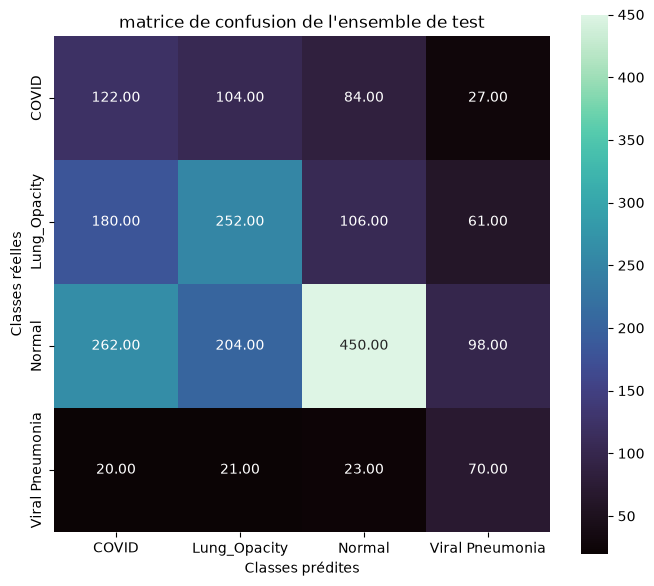

In [25]:
#Évaluation sur l'ensemble de test

y_test_pred=modelknn.predict(X_test_scaled)

cm_test=pd.crosstab(y_test, y_test_pred, colnames=["Classes prédites"], rownames=["Classes réelles"])

print(classification_report(y_test, y_test_pred))

display(cm_test)

figure_1=plt.figure(figsize=(8,7))

sns.heatmap(cm_test, annot=True, square=True, fmt=".2f", cmap="mako")

plt.title("matrice de confusion de l'ensemble de test")

plt.show()


7. Optimisation du modèle

In [22]:
#Initialisation de la grille et de ses paramètres puis entraînement sur les données d'entraînement

parametres={"n_neighbors":np.arange(3,15), "weights":["uniform", "distance"], "metric":["euclidian", "minkowski", "manhattan", "chebyshev"]}

modelKNN=KNeighborsClassifier()

grille=GridSearchCV(modelKNN, parametres, scoring="f1_macro", cv=5)
resultats_grille=grille.fit(X_train_resampled, y_train_resampled)

/opt/anaconda3/envs/Liora/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
120 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/Liora/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/envs/Liora/lib/python3.11/site-packages/sklearn/base.py", line 1393, in wrapper
    estimator._validate_params()
  File "/opt/anaconda3/envs/Liora/lib/python3.11/site-packages/sklearn/base.py", line 554, in _validate_params
    validate_parameter_constraints(


In [23]:
#Résultats de la grille

print("Paramètres les plus performants : ", resultats_grille.best_params_)

print(f"Meilleur f1-score : {grille.best_score_}")

Paramètres les plus performants :  {'metric': 'minkowski', 'n_neighbors': np.int64(4), 'weights': 'distance'}
Meilleur f1-score : 0.8135601219085901


8. Initialisation d'un nouveau modèle à partir des résultats de la validation croisée

In [24]:

#Paramétrage et entraînement du nouveau modèle
modelKNN_best=KNeighborsClassifier(n_neighbors=resultats_grille.best_params_["n_neighbors"], weights=resultats_grille.best_params_["weights"], metric=resultats_grille.best_params_["metric"])
modelKNN_fitted=modelKNN_best.fit(X_train_resampled, y_train_resampled)


9. Évaluation du nouveau modèle

                 precision    recall  f1-score   support

          COVID       0.21      0.29      0.24       337
   Lung_Opacity       0.45      0.45      0.45       599
         Normal       0.67      0.52      0.59      1014
Viral Pneumonia       0.31      0.49      0.37       134

       accuracy                           0.46      2084
      macro avg       0.41      0.44      0.41      2084
   weighted avg       0.51      0.46      0.48      2084



Classes prédites,COVID,Lung_Opacity,Normal,Viral Pneumonia
Classes réelles,,,,
COVID,98,112,101,26
Lung_Opacity,147,272,132,48
Normal,205,203,532,74
Viral Pneumonia,18,24,27,65


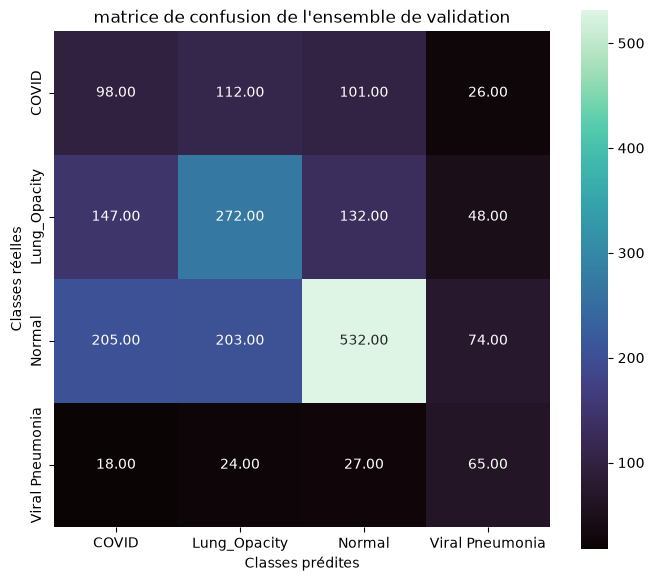

In [26]:
#Sur l'ensemble de test

y_test_best_pred=modelKNN_fitted.predict(X_test_scaled)

cm_test_best=pd.crosstab(y_test, y_test_best_pred, colnames=["Classes prédites"], rownames=["Classes réelles"])

print(classification_report(y_test, y_test_best_pred))

display(cm_test_best)

figure_3=plt.figure(figsize=(8,7))

sns.heatmap(cm_test_best, annot=True, square=True, fmt=".2f", cmap="mako")

plt.title("matrice de confusion de l'ensemble de validation")

plt.show()